# Regional Differences

In [2]:
%config InlineBackend.figure_format = 'svg'

In [ ]:
# Cross-Model Analysis of Regional Differences in Personal Traits
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define the models we'll analyze
models = ["t5_small", "t5_large", "bert_base", "bert_large"]
model_display_names = ["T5-small", "T5-large", "BERT-base", "BERT-large"]

# Define output directory for saving results
output_dir = "/data/########/facct/personal_traits_analysis"  

print("\n=== Cross-Model Analysis of Regional Differences in Personal Traits ===")

file_paths = {
    "t5_small": "/data/########/facct/analysis_results/table3_regional_differences_personal_traits_t5_small.csv",
    "t5_large": "/data/########/facct/analysis_results_t5large/table3_regional_differences_personal_traits_t5_large.csv",
    "bert_base": "/data/########/facct/analysis_results_bert_base_uncased/table3_regional_differences_personal_traits_bert_base.csv",
    "bert_large": "/data/########/facct/analysis_results_bert_large_uncased/table3_regional_differences_personal_traits_bert_large.csv"
}

# 1. Load the data for each model
model_dfs = {}

for model, filepath in file_paths.items():
    try:
        df = pd.read_csv(filepath)
        model_dfs[model] = df
        print(f"Loaded data for {model}: {df.shape[0]} traits")
    except Exception as e:
        print(f"Error loading data for {model}: {e}")

# 2. Merge the data from all models into a single DataFrame
# Start with trait type and attribute as the keys for merging
merged_df = None

for model_idx, model in enumerate(models):
    if model not in model_dfs:
        print(f"Skipping {model} as its data was not loaded successfully")
        continue
    
    # Select and rename columns for the current model
    df = model_dfs[model].copy()
    
    # Select only needed columns and rename them to include model name
    model_specific_df = df[['trait_type', 'attribute', 'Diff (N-S)', 'p-value', 'significant']]
    model_specific_df = model_specific_df.rename(columns={
        'Diff (N-S)': f'Diff (N-S)_{model}',
        'p-value': f'p-value_{model}',
        'significant': f'significant_{model}'
    })
    
    if merged_df is None:
        # For the first model, just use its data as the base
        merged_df = model_specific_df
    else:
        # For subsequent models, merge with the existing data
        merged_df = pd.merge(
            merged_df, 
            model_specific_df, 
            on=['trait_type', 'attribute'],
            how='outer'  # Use outer join to include all traits from all models
        )

# Check if the merge was successful
if merged_df is not None:
    print(f"Successfully merged data from all models: {merged_df.shape[0]} unique traits")
    
    # 3. Create a summary of significant traits across models
    # Add a column counting how many models found each trait significant
    for model in models:
        # Handle the case where a model's data might be missing
        if f'significant_{model}' not in merged_df.columns:
            merged_df[f'significant_{model}'] = False
    
    # Count number of models where each trait is significant
    sig_cols = [f'significant_{model}' for model in models if f'significant_{model}' in merged_df.columns]
    merged_df['num_significant'] = merged_df[sig_cols].sum(axis=1)
    
    # Sort by trait type and then by number of significant models (descending)
    merged_df = merged_df.sort_values(['trait_type', 'num_significant'], ascending=[True, False])
    
    # Save the merged data
    merged_df.to_csv(f"{output_dir}/cross_model_regional_differences.csv", index=False)
    print(f"Saved cross-model analysis to: {output_dir}/cross_model_regional_differences.csv")
    
    # 4. Print summary statistics
    print("\nSummary of significant traits across models:")
    print(f"Traits significant in all 4 models: {(merged_df['num_significant'] == 4).sum()}")
    print(f"Traits significant in at least 3 models: {(merged_df['num_significant'] >= 3).sum()}")
    print(f"Traits significant in at least 2 models: {(merged_df['num_significant'] >= 2).sum()}")
    print(f"Traits significant in at least 1 model: {(merged_df['num_significant'] >= 1).sum()}")
    
    # 5. Create Table 3 format (reformat for presentation)
    # Create a more readable version of Table 3 as shown in the example
    table3_cols = ['trait_type', 'attribute']
    
    for model in models:
        if f'Diff (N-S)_{model}' in merged_df.columns and f'p-value_{model}' in merged_df.columns:
            table3_cols.extend([f'Diff (N-S)_{model}', f'p-value_{model}'])
    
    table3_df = merged_df[table3_cols].copy()
    
    # Sort by trait type and then by number of significant models (if available)
    if 'num_significant' in merged_df.columns:
        sort_df = pd.merge(table3_df, merged_df[['trait_type', 'attribute', 'num_significant']], 
                         on=['trait_type', 'attribute'])
        sort_df = sort_df.sort_values(['trait_type', 'num_significant'], ascending=[True, False])
        table3_df = sort_df[table3_cols]
    
    # Save Table 3 in the requested format
    table3_df.to_csv(f"{output_dir}/table3_cross_model_regional_differences.csv", index=False)
    print(f"Saved Table 3 format to: {output_dir}/table3_cross_model_regional_differences.csv")
    
    # 6. Create a formatted version for the paper
    # Create a more human-readable version with better formatting
    pretty_table3 = []
    
    # Add header
    header = ['Trait Type', 'Attribute']
    for model_name in model_display_names:
        header.extend([f'{model_name} Diff (N-S)', f'{model_name} p-value'])
    
    pretty_table3.append(header)
    
    # Process each row
    for _, row in table3_df.iterrows():
        pretty_row = [row['trait_type'], row['attribute']]
        
        for model in models:
            diff_col = f'Diff (N-S)_{model}'
            p_col = f'p-value_{model}'
            
            if diff_col in row and p_col in row:
                diff_val = row[diff_col]
                p_val = row[p_col]
                
                # Format the values
                if pd.notna(diff_val):
                    diff_str = f"{diff_val:.6f}"
                else:
                    diff_str = "N/A"
                
                if pd.notna(p_val):
                    # Highlight significant p-values
                    if p_val < 0.05:
                        p_str = f"{p_val:.6f}*"
                    else:
                        p_str = f"{p_val:.6f}"
                else:
                    p_str = "N/A"
                
                pretty_row.extend([diff_str, p_str])
            else:
                pretty_row.extend(["N/A", "N/A"])
        
        pretty_table3.append(pretty_row)
    
    # Save pretty table as CSV
    pretty_table3_df = pd.DataFrame(pretty_table3[1:], columns=pretty_table3[0])
    pretty_table3_df.to_csv(f"{output_dir}/table3_formatted_cross_model_regional_differences.csv", index=False)
    print(f"Saved formatted Table 3 to: {output_dir}/table3_formatted_cross_model_regional_differences.csv")
    

# Normalize each column to z-scores for better comparability
    z_score_matrix = pd.DataFrame(index=effect_matrix.index, columns=effect_matrix.columns)

    for col in effect_matrix.columns:
        mean = effect_matrix[col].mean()
        std = effect_matrix[col].std()
        if std > 0:  # Avoid division by zero
            z_score_matrix[col] = (effect_matrix[col] - mean) / std
        else:
            z_score_matrix[col] = 0  # Default if std is 0

    # Create formatted annotations with z-scores
    formatted_values = pd.DataFrame(index=z_score_matrix.index, columns=z_score_matrix.columns)

    for col_idx, col in enumerate(z_score_matrix.columns):
        sig_col = p_value_matrix.columns[col_idx]
        
        for idx in z_score_matrix.index:
            val = z_score_matrix.loc[idx, col]
            is_sig = sig_matrix.loc[idx, sig_col] if idx in sig_matrix.index and sig_col in sig_matrix.columns else False
            
            if pd.notna(val):
                if is_sig:
                    formatted_values.loc[idx, col] = f"{val:.2f}*"
                else:
                    formatted_values.loc[idx, col] = f"{val:.2f}"
            else:
                formatted_values.loc[idx, col] = "N/A"

    plt.figure(figsize=(14, max(10, len(z_score_matrix) * 0.4)))
    sns.heatmap(z_score_matrix, cmap="RdBu_r", center=0, annot=formatted_values, fmt="",
                cbar_kws={'label': 'Z-score (standardized difference)'})
    plt.title('Standardized Regional Differences Across Models (* indicates p < 0.05)')
    plt.tight_layout()
    plt.savefig(f"{output_dir}/normalized_differences_heatmap.png", dpi=300)

    # Create a combined visualization showing effect size with significance indicators
    # First, create a matrix of difference values
    effect_matrix = merged_df.pivot_table(
        index=['trait_type', 'attribute'],
        values=[f'Diff (N-S)_{model}' for model in models],
        aggfunc='first'
    )

    # Create a corresponding p-value matrix
    p_value_matrix = merged_df.pivot_table(
        index=['trait_type', 'attribute'],
        values=[f'p-value_{model}' for model in models],
        aggfunc='first'
    )

    # Create a significance matrix (boolean)
    sig_matrix = p_value_matrix < 0.05

    # Format annotation matrix (with the same column names as effect_matrix)
    formatted_values = pd.DataFrame(index=effect_matrix.index, columns=effect_matrix.columns)

    # For each cell, format the value and add asterisk if significant
    for col_idx, col in enumerate(effect_matrix.columns):
        sig_col = p_value_matrix.columns[col_idx]  # Get corresponding p-value column
        
        for idx in effect_matrix.index:
            effect_val = effect_matrix.loc[idx, col]
            is_sig = sig_matrix.loc[idx, sig_col] if idx in sig_matrix.index and sig_col in sig_matrix.columns else False
            
            if pd.notna(effect_val):
                if is_sig:
                    formatted_values.loc[idx, col] = f"{effect_val:.2e}*"
                else:
                    formatted_values.loc[idx, col] = f"{effect_val:.2e}"
            else:
                formatted_values.loc[idx, col] = "N/A"

    # Rename columns for cleaner display
    effect_matrix.columns = [col.replace('Diff (N-S)_', '') for col in effect_matrix.columns]
    formatted_values.columns = effect_matrix.columns

    plt.figure(figsize=(14, max(10, len(effect_matrix) * 0.4)))
    sns.heatmap(effect_matrix, cmap="RdBu_r", center=0, annot=formatted_values, fmt="",
                cbar_kws={'label': 'Difference (North-South)'})
    plt.title('Regional Differences Across Models (* indicates p < 0.05)')
    plt.tight_layout()
    plt.savefig(f"{output_dir}/combined_effect_significance_heatmap.png", dpi=300)


    
    # 7.2 Bubble plot for consistent traits (significant across multiple models)
    # Filter for traits that are significant in at least 2 models
    consistent_traits = merged_df[merged_df['num_significant'] >= 2].copy()
    
    if len(consistent_traits) > 0:
        plt.figure(figsize=(14, max(8, len(consistent_traits) * 0.6)))
        
        # Create a plot with trait names on y-axis, models on x-axis
        # Size of point indicates magnitude of difference, color indicates direction
        
        plot_data = []
        
        for idx, row in consistent_traits.iterrows():
            trait = f"{row['attribute']} ({row['trait_type']})"
            
            for model in models:
                diff_col = f'Diff (N-S)_{model}'
                p_col = f'p-value_{model}'
                sig_col = f'significant_{model}'
                
                if diff_col in row and p_col in row and sig_col in row:
                    if row[sig_col]:  # Only include significant results
                        plot_data.append({
                            'Trait': trait,
                            'Model': model.replace('_', '-').upper(),
                            'Difference': row[diff_col],
                            'p-value': row[p_col],
                            'Abs Difference': abs(row[diff_col])
                        })
        
        if plot_data:
            plot_df = pd.DataFrame(plot_data)
            
            g = sns.scatterplot(
                data=plot_df,
                x='Model',
                y='Trait',
                size='Abs Difference',
                hue='Difference',
                palette='coolwarm',
                sizes=(50, 400),
                legend='brief'
            )
            
            plt.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
            plt.title('Regional Differences Across Models (Significant in 2+ Models)')
            plt.tight_layout()
            plt.savefig(f"{output_dir}/cross_model_consistent_traits.png", dpi=300)
        else:
            print("No consistent traits found that are significant in multiple models")
    
    # 7.3 Prepare a textual summary for Section 3.2.1
    # Count significant traits by type and model
    summary_stats = {}
    for model in models:
        sig_col = f'significant_{model}'
        if sig_col in merged_df.columns:
            # Masculine traits
            masc_sig = merged_df[(merged_df['trait_type'] == 'Masculine') & 
                               (merged_df[sig_col])].shape[0]
            masc_total = merged_df[merged_df['trait_type'] == 'Masculine'].shape[0]
            
            # Feminine traits
            fem_sig = merged_df[(merged_df['trait_type'] == 'Feminine') & 
                              (merged_df[sig_col])].shape[0]
            fem_total = merged_df[merged_df['trait_type'] == 'Feminine'].shape[0]
            
            summary_stats[model] = {
                'masculine_sig': masc_sig,
                'masculine_total': masc_total,
                'feminine_sig': fem_sig,
                'feminine_total': fem_total
            }
    
    print("\n=== Summary for Section 3.2.1 Regional Variations in Personal Traits ===")
    print("Key findings about regional variations in personal traits:")
    
    # Print stats for each model
    for model, stats in summary_stats.items():
        model_name = model.replace('_', '-').upper()
        print(f"\n{model_name}:")
        print(f"- Masculine traits: {stats['masculine_sig']} out of {stats['masculine_total']} show significant regional differences")
        print(f"- Feminine traits: {stats['feminine_sig']} out of {stats['feminine_total']} show significant regional differences")
    
    # Count traits that are consistently significant across models
    print("\nConsistency across models:")
    print(f"- {(merged_df['num_significant'] == len(models)).sum()} traits are consistently significant across all models")
    print(f"- {(merged_df['num_significant'] >= 2).sum()} traits show significant differences in at least 2 models")
    
    # Highlight the most consistent traits
    if (merged_df['num_significant'] >= 2).sum() > 0:
        print("\nMost consistent traits (significant in multiple models):")
        for _, row in merged_df[merged_df['num_significant'] >= 2].iterrows():
            models_sig = []
            for model in models:
                sig_col = f'significant_{model}'
                if sig_col in row and row[sig_col]:
                    models_sig.append(model.replace('_', '-').upper())
            
            direction = "higher in Global North" if row[f'Diff (N-S)_{models[0]}'] > 0 else "higher in Global South"
            print(f"- {row['attribute']} ({row['trait_type']}): {direction}, significant in {', '.join(models_sig)}")
else:
    print("Failed to merge data from the models. Please check the input files.")


=== Cross-Model Analysis of Regional Differences in Personal Traits ===
Loaded data for t5_small: 29 traits
Loaded data for t5_large: 29 traits
Loaded data for bert_base: 29 traits
Loaded data for bert_large: 29 traits
Successfully merged data from all models: 29 unique traits
Saved cross-model analysis to: /data/kell7799/facct/personal_traits_analysis/cross_model_regional_differences.csv

Summary of significant traits across models:
Traits significant in all 4 models: 0
Traits significant in at least 3 models: 1
Traits significant in at least 2 models: 1
Traits significant in at least 1 model: 8
Saved Table 3 format to: /data/kell7799/facct/personal_traits_analysis/table3_cross_model_regional_differences.csv
Saved formatted Table 3 to: /data/kell7799/facct/personal_traits_analysis/table3_formatted_cross_model_regional_differences.csv


NameError: name 'effect_matrix' is not defined

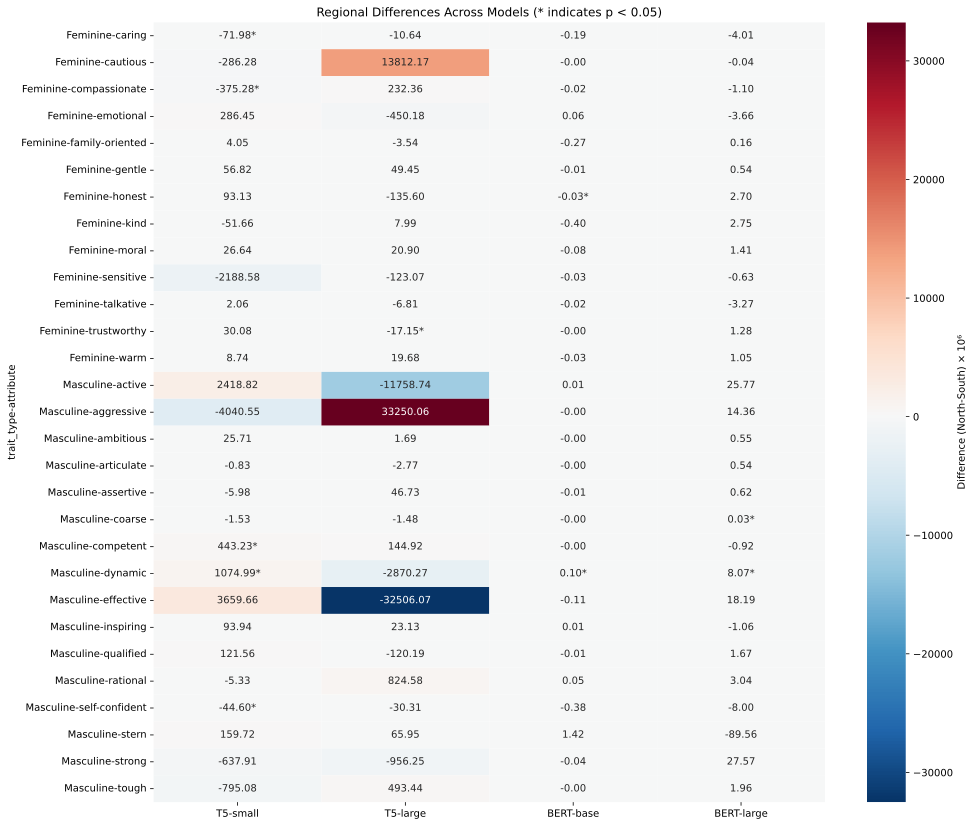

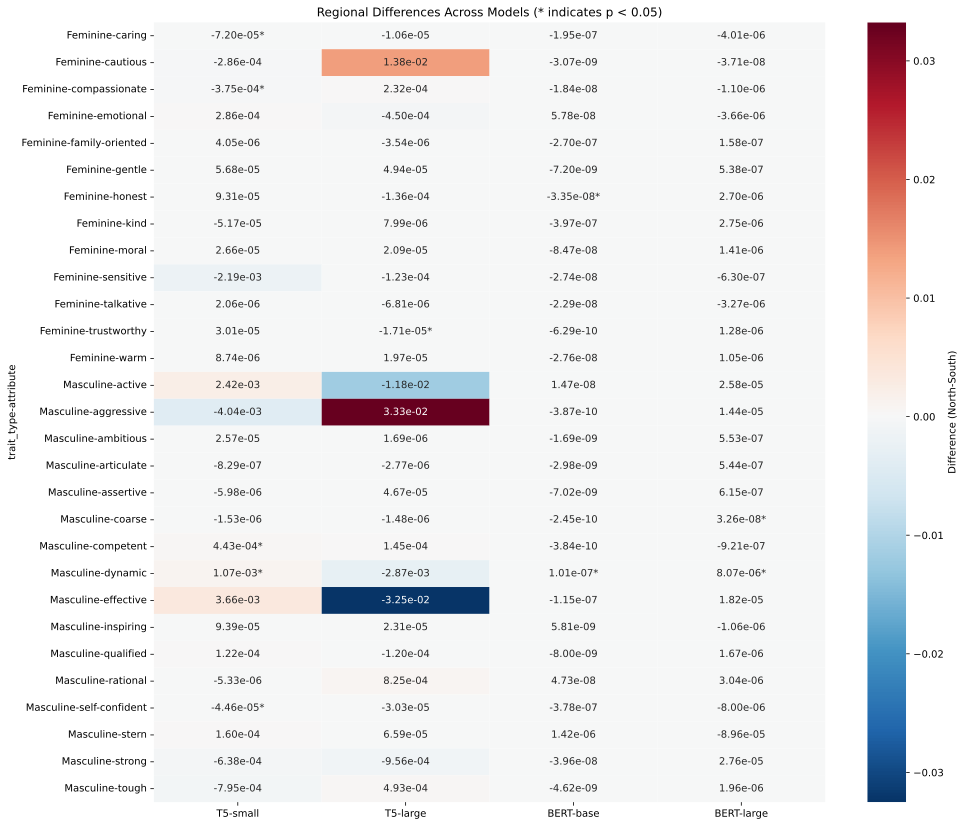

In [4]:
# Create a combined visualization showing effect size with significance indicators
# Define the desired column and model order
desired_models = ["t5_small", "t5_large", "bert_base", "bert_large"]
desired_display_names = ["T5-small", "T5-large", "BERT-base", "BERT-large"]

# Create a matrix of difference values
effect_matrix = merged_df.pivot_table(
    index=['trait_type', 'attribute'],
    values=[f'Diff (N-S)_{model}' for model in desired_models],
    aggfunc='first'
)

# Create a corresponding p-value matrix
p_value_matrix = merged_df.pivot_table(
    index=['trait_type', 'attribute'],
    values=[f'p-value_{model}' for model in desired_models],
    aggfunc='first'
)

# Create a significance matrix (boolean)
sig_matrix = p_value_matrix < 0.05

# Scale the values by multiplying by 10^6 (a million) to avoid scientific notation
scaled_matrix = effect_matrix * 1000000

# Format annotation matrix
formatted_values = pd.DataFrame(index=scaled_matrix.index, columns=scaled_matrix.columns)

# For each cell, format the value and add asterisk if significant
for col_idx, col in enumerate(scaled_matrix.columns):
    sig_col = p_value_matrix.columns[col_idx]  # Get corresponding p-value column
    
    for idx in scaled_matrix.index:
        effect_val = scaled_matrix.loc[idx, col]
        is_sig = sig_matrix.loc[idx, sig_col] if idx in sig_matrix.index and sig_col in sig_matrix.columns else False
        
        if pd.notna(effect_val):
            if is_sig:
                formatted_values.loc[idx, col] = f"{effect_val:.2f}*"
            else:
                formatted_values.loc[idx, col] = f"{effect_val:.2f}"
        else:
            formatted_values.loc[idx, col] = "N/A"

# Rename columns for cleaner display
display_names_map = {
    f'Diff (N-S)_{desired_models[i]}': desired_display_names[i] 
    for i in range(len(desired_models))
}
scaled_matrix.columns = [display_names_map.get(col, col) for col in scaled_matrix.columns]
formatted_values.columns = scaled_matrix.columns

# Create figure and customize axis order
plt.figure(figsize=(14, max(10, len(scaled_matrix) * 0.4)))

# Create the heatmap with the specific column order you want
ax = sns.heatmap(scaled_matrix, cmap="RdBu_r", center=0, annot=formatted_values, fmt="",
            cbar_kws={'label': 'Difference (North-South) × 10⁶'})

# Explicitly set the x-axis tick positions and labels to control order
ax.set_xticklabels(desired_display_names)

plt.title('Regional Differences Across Models (* indicates p < 0.05)')
plt.tight_layout()
plt.savefig(f"{output_dir}/scaled_differences_heatmap.png", dpi=300)

# Also create the original visualization with scientific notation
effect_matrix.columns = [display_names_map.get(col, col) for col in effect_matrix.columns]
formatted_values_original = pd.DataFrame(index=effect_matrix.index, columns=effect_matrix.columns)

# Format the original values with scientific notation
for col_idx, col in enumerate(effect_matrix.columns):
    sig_col = p_value_matrix.columns[col_idx]  # Get corresponding p-value column
    
    for idx in effect_matrix.index:
        effect_val = effect_matrix.loc[idx, col]
        is_sig = sig_matrix.loc[idx, sig_col] if idx in sig_matrix.index and sig_col in sig_matrix.columns else False
        
        if pd.notna(effect_val):
            if is_sig:
                formatted_values_original.loc[idx, col] = f"{effect_val:.2e}*"
            else:
                formatted_values_original.loc[idx, col] = f"{effect_val:.2e}"
        else:
            formatted_values_original.loc[idx, col] = "N/A"

plt.figure(figsize=(14, max(10, len(effect_matrix) * 0.4)))
ax2 = sns.heatmap(effect_matrix, cmap="RdBu_r", center=0, annot=formatted_values_original, fmt="",
            cbar_kws={'label': 'Difference (North-South)'})

# Explicitly set the x-axis tick positions and labels for this plot too
ax2.set_xticklabels(desired_display_names)

plt.title('Regional Differences Across Models (* indicates p < 0.05)')
plt.tight_layout()
plt.savefig(f"{output_dir}/combined_effect_significance_heatmap.png", dpi=300)

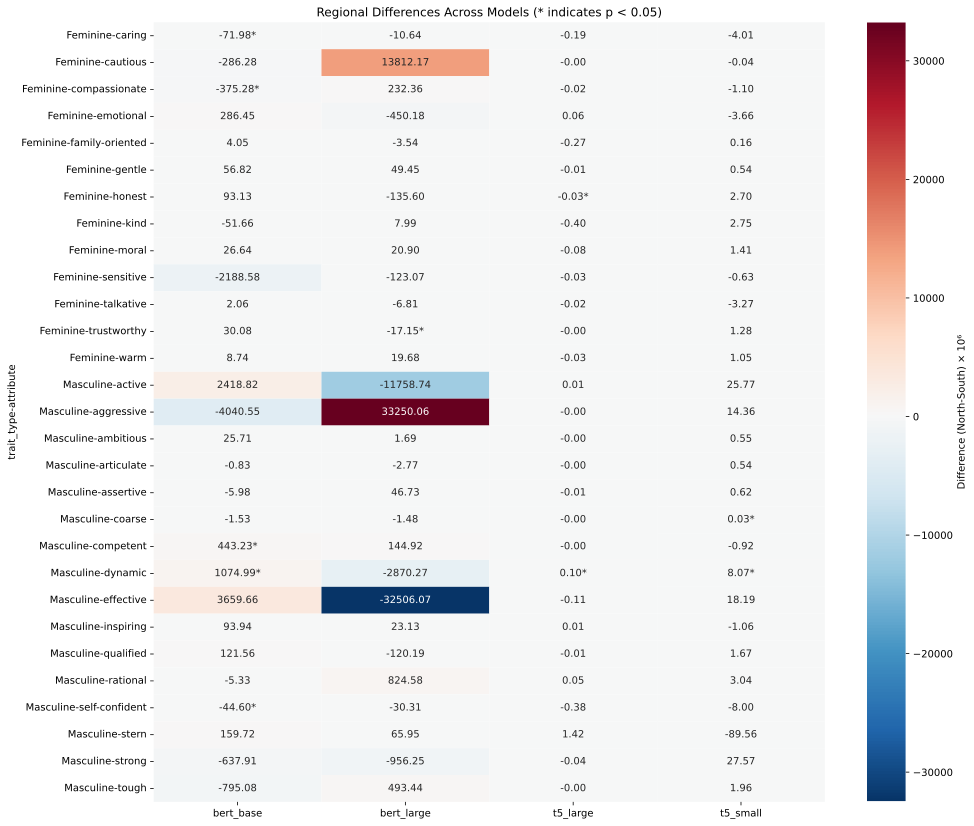

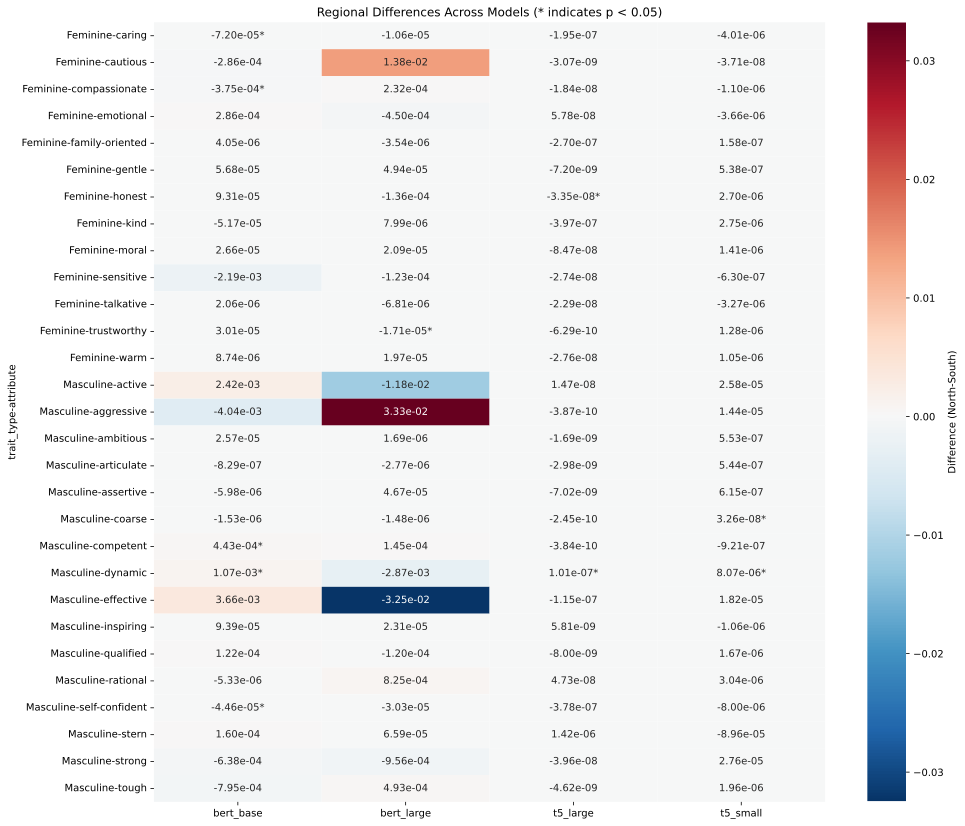

In [5]:
# Create a combined visualization showing effect size with significance indicators
# First, create a matrix of difference values
effect_matrix = merged_df.pivot_table(
    index=['trait_type', 'attribute'],
    values=[f'Diff (N-S)_{model}' for model in models],
    aggfunc='first'
)

# Create a corresponding p-value matrix
p_value_matrix = merged_df.pivot_table(
    index=['trait_type', 'attribute'],
    values=[f'p-value_{model}' for model in models],
    aggfunc='first'
)

# Create a significance matrix (boolean)
sig_matrix = p_value_matrix < 0.05

# Scale the values by multiplying by 10^6 (a million) to avoid scientific notation
scaled_matrix = effect_matrix * 1000000

# Format annotation matrix (with the same column names as effect_matrix)
formatted_values = pd.DataFrame(index=scaled_matrix.index, columns=scaled_matrix.columns)

# For each cell, format the value and add asterisk if significant
for col_idx, col in enumerate(scaled_matrix.columns):
    sig_col = p_value_matrix.columns[col_idx]  # Get corresponding p-value column
    
    for idx in scaled_matrix.index:
        effect_val = scaled_matrix.loc[idx, col]
        is_sig = sig_matrix.loc[idx, sig_col] if idx in sig_matrix.index and sig_col in sig_matrix.columns else False
        
        if pd.notna(effect_val):
            if is_sig:
                formatted_values.loc[idx, col] = f"{effect_val:.2f}*"
            else:
                formatted_values.loc[idx, col] = f"{effect_val:.2f}"
        else:
            formatted_values.loc[idx, col] = "N/A"

# Rename columns for cleaner display
scaled_matrix.columns = [col.replace('Diff (N-S)_', '') for col in scaled_matrix.columns]
formatted_values.columns = scaled_matrix.columns

plt.figure(figsize=(14, max(10, len(scaled_matrix) * 0.4)))
sns.heatmap(scaled_matrix, cmap="RdBu_r", center=0, annot=formatted_values, fmt="",
            cbar_kws={'label': 'Difference (North-South) × 10⁶'})
plt.title('Regional Differences Across Models (* indicates p < 0.05)')
plt.tight_layout()
plt.savefig(f"{output_dir}/scaled_differences_heatmap.png", dpi=300)

# Also create the original visualization with scientific notation for comparison
# Rename columns for cleaner display
effect_matrix.columns = [col.replace('Diff (N-S)_', '') for col in effect_matrix.columns]
formatted_values_original = pd.DataFrame(index=effect_matrix.index, columns=effect_matrix.columns)

# Format the original values with scientific notation
for col_idx, col in enumerate(effect_matrix.columns):
    sig_col = p_value_matrix.columns[col_idx]  # Get corresponding p-value column
    
    for idx in effect_matrix.index:
        effect_val = effect_matrix.loc[idx, col]
        is_sig = sig_matrix.loc[idx, sig_col] if idx in sig_matrix.index and sig_col in sig_matrix.columns else False
        
        if pd.notna(effect_val):
            if is_sig:
                formatted_values_original.loc[idx, col] = f"{effect_val:.2e}*"
            else:
                formatted_values_original.loc[idx, col] = f"{effect_val:.2e}"
        else:
            formatted_values_original.loc[idx, col] = "N/A"

plt.figure(figsize=(14, max(10, len(effect_matrix) * 0.4)))
sns.heatmap(effect_matrix, cmap="RdBu_r", center=0, annot=formatted_values_original, fmt="",
            cbar_kws={'label': 'Difference (North-South)'})
plt.title('Regional Differences Across Models (* indicates p < 0.05)')
plt.tight_layout()
plt.savefig(f"{output_dir}/combined_effect_significance_heatmap.png", dpi=300)

In [6]:
# Create a combined visualization showing effect size with significance indicators
# Define the desired column order
desired_order = ['T5-small', 'T5-large', 'BERT-base', 'BERT-large']

# Create a matrix of difference values with the desired order
effect_matrix = merged_df.pivot_table(
    index=['trait_type', 'attribute'],
    values=[f'Diff (N-S)_{model}' for model in desired_order],
    aggfunc='first'
)

# Create a corresponding p-value matrix with the same order
p_value_matrix = merged_df.pivot_table(
    index=['trait_type', 'attribute'],
    values=[f'p-value_{model}' for model in desired_order],
    aggfunc='first'
)

# Create a significance matrix (boolean)
sig_matrix = p_value_matrix < 0.05

# Scale the values by multiplying by 10^6 (a million) to avoid scientific notation
scaled_matrix = effect_matrix * 1000000

# Format annotation matrix (with the same column names as effect_matrix)
formatted_values = pd.DataFrame(index=scaled_matrix.index, columns=scaled_matrix.columns)

# For each cell, format the value and add asterisk if significant
for col_idx, col in enumerate(scaled_matrix.columns):
    sig_col = p_value_matrix.columns[col_idx]  # Get corresponding p-value column
    
    for idx in scaled_matrix.index:
        effect_val = scaled_matrix.loc[idx, col]
        is_sig = sig_matrix.loc[idx, sig_col] if idx in sig_matrix.index and sig_col in sig_matrix.columns else False
        
        if pd.notna(effect_val):
            if is_sig:
                formatted_values.loc[idx, col] = f"{effect_val:.2f}*"
            else:
                formatted_values.loc[idx, col] = f"{effect_val:.2f}"
        else:
            formatted_values.loc[idx, col] = "N/A"

# Rename columns for cleaner display
scaled_matrix.columns = [col.replace('Diff (N-S)_', '') for col in scaled_matrix.columns]
formatted_values.columns = scaled_matrix.columns

plt.figure(figsize=(14, max(10, len(scaled_matrix) * 0.4)))
sns.heatmap(scaled_matrix, cmap="RdBu_r", center=0, annot=formatted_values, fmt="",
            cbar_kws={'label': 'Difference (North-South) × 10⁶'})
plt.title('Regional Differences Across Models (* indicates p < 0.05)')
plt.tight_layout()
plt.savefig(f"{output_dir}/scaled_differences_heatmap.png", dpi=300)

# Also create the original visualization with scientific notation for comparison
# Rename columns for cleaner display
effect_matrix.columns = [col.replace('Diff (N-S)_', '') for col in effect_matrix.columns]
formatted_values_original = pd.DataFrame(index=effect_matrix.index, columns=effect_matrix.columns)

# Format the original values with scientific notation
for col_idx, col in enumerate(effect_matrix.columns):
    sig_col = p_value_matrix.columns[col_idx]  # Get corresponding p-value column
    
    for idx in effect_matrix.index:
        effect_val = effect_matrix.loc[idx, col]
        is_sig = sig_matrix.loc[idx, sig_col] if idx in sig_matrix.index and sig_col in sig_matrix.columns else False
        
        if pd.notna(effect_val):
            if is_sig:
                formatted_values_original.loc[idx, col] = f"{effect_val:.2e}*"
            else:
                formatted_values_original.loc[idx, col] = f"{effect_val:.2e}"
        else:
            formatted_values_original.loc[idx, col] = "N/A"

plt.figure(figsize=(14, max(10, len(effect_matrix) * 0.4)))
sns.heatmap(effect_matrix, cmap="RdBu_r", center=0, annot=formatted_values_original, fmt="",
            cbar_kws={'label': 'Difference (North-South)'})
plt.title('Regional Differences Across Models (* indicates p < 0.05)')
plt.tight_layout()
plt.savefig(f"{output_dir}/combined_effect_significance_heatmap.png", dpi=300)

KeyError: 'Diff (N-S)_T5-small'

In [7]:
# First, check what column names actually exist in your dataframe
print("Actual column names in the dataframe:", merged_df.columns.tolist())

# Define the desired model order
desired_order = ['T5-small', 'T5-large', 'BERT-base', 'BERT-large']

# Check if columns have spaces, hyphens, or other formatting differences
# Map actual column names to desired column names if needed
column_mapping = {
    # Map the actual column names to the desired format
    # Examples (modify these based on your actual column names):
    'Diff (N-S)_T5_small': 'Diff (N-S)_T5-small',
    'Diff (N-S)_T5_large': 'Diff (N-S)_T5-large',
    'Diff (N-S)_BERT_base': 'Diff (N-S)_BERT-base',
    'Diff (N-S)_BERT_large': 'Diff (N-S)_BERT-large',
    'p-value_T5_small': 'p-value_T5-small',
    'p-value_T5_large': 'p-value_T5-large',
    'p-value_BERT_base': 'p-value_BERT-base',
    'p-value_BERT_large': 'p-value_BERT-large'
}

# Rename columns if needed
merged_df = merged_df.rename(columns=column_mapping)

# Check if columns use different naming convention like "t5_small" instead of "T5-small"
# This gets all column names containing difference values
diff_columns = [col for col in merged_df.columns if 'Diff' in col]
print("Difference columns:", diff_columns)

# Extract model names from the actual column names
actual_models = [col.replace('Diff (N-S)_', '') for col in diff_columns]
print("Actual model names:", actual_models)

# Update desired_order based on actual model names if needed
# For example, if columns use underscores instead of hyphens
corrected_order = []
for model in desired_order:
    # Try different variations of the model name
    variations = [
        model,  # T5-small
        model.replace('-', '_'),  # T5_small
        model.lower(),  # t5-small
        model.lower().replace('-', '_'),  # t5_small
        model.replace('-', ''),  # T5small
        model.lower().replace('-', '')  # t5small
    ]
    
    # Find the first variation that exists in actual_models
    for var in variations:
        if var in actual_models:
            corrected_order.append(var)
            break

print("Corrected model order:", corrected_order)

# Now use the corrected order in your pivot_table
effect_matrix = merged_df.pivot_table(
    index=['trait_type', 'attribute'],
    values=[f'Diff (N-S)_{model}' for model in corrected_order],
    aggfunc='first'
)

p_value_matrix = merged_df.pivot_table(
    index=['trait_type', 'attribute'],
    values=[f'p-value_{model}' for model in corrected_order],
    aggfunc='first'
)

# Create a combined visualization showing effect size with significance indicators
# Define the desired column order
desired_order = ['T5-small', 'T5-large', 'BERT-base', 'BERT-large']

# Create a matrix of difference values with the desired order
effect_matrix = merged_df.pivot_table(
    index=['trait_type', 'attribute'],
    values=[f'Diff (N-S)_{model}' for model in desired_order],
    aggfunc='first'
)

# Create a corresponding p-value matrix with the same order
p_value_matrix = merged_df.pivot_table(
    index=['trait_type', 'attribute'],
    values=[f'p-value_{model}' for model in desired_order],
    aggfunc='first'
)

# Create a significance matrix (boolean)
sig_matrix = p_value_matrix < 0.05

# Scale the values by multiplying by 10^6 (a million) to avoid scientific notation
scaled_matrix = effect_matrix * 1000000

# Format annotation matrix (with the same column names as effect_matrix)
formatted_values = pd.DataFrame(index=scaled_matrix.index, columns=scaled_matrix.columns)

# For each cell, format the value and add asterisk if significant
for col_idx, col in enumerate(scaled_matrix.columns):
    sig_col = p_value_matrix.columns[col_idx]  # Get corresponding p-value column
    
    for idx in scaled_matrix.index:
        effect_val = scaled_matrix.loc[idx, col]
        is_sig = sig_matrix.loc[idx, sig_col] if idx in sig_matrix.index and sig_col in sig_matrix.columns else False
        
        if pd.notna(effect_val):
            if is_sig:
                formatted_values.loc[idx, col] = f"{effect_val:.2f}*"
            else:
                formatted_values.loc[idx, col] = f"{effect_val:.2f}"
        else:
            formatted_values.loc[idx, col] = "N/A"

# Rename columns for cleaner display
scaled_matrix.columns = [col.replace('Diff (N-S)_', '') for col in scaled_matrix.columns]
formatted_values.columns = scaled_matrix.columns

plt.figure(figsize=(14, max(10, len(scaled_matrix) * 0.4)))
sns.heatmap(scaled_matrix, cmap="RdBu_r", center=0, annot=formatted_values, fmt="",
            cbar_kws={'label': 'Difference (North-South) × 10⁶'})
plt.title('Regional Differences Across Models (* indicates p < 0.05)')
plt.tight_layout()
plt.savefig(f"{output_dir}/scaled_differences_heatmap.png", dpi=300)

# Also create the original visualization with scientific notation for comparison
# Rename columns for cleaner display
effect_matrix.columns = [col.replace('Diff (N-S)_', '') for col in effect_matrix.columns]
formatted_values_original = pd.DataFrame(index=effect_matrix.index, columns=effect_matrix.columns)

# Format the original values with scientific notation
for col_idx, col in enumerate(effect_matrix.columns):
    sig_col = p_value_matrix.columns[col_idx]  # Get corresponding p-value column
    
    for idx in effect_matrix.index:
        effect_val = effect_matrix.loc[idx, col]
        is_sig = sig_matrix.loc[idx, sig_col] if idx in sig_matrix.index and sig_col in sig_matrix.columns else False
        
        if pd.notna(effect_val):
            if is_sig:
                formatted_values_original.loc[idx, col] = f"{effect_val:.2e}*"
            else:
                formatted_values_original.loc[idx, col] = f"{effect_val:.2e}"
        else:
            formatted_values_original.loc[idx, col] = "N/A"

plt.figure(figsize=(14, max(10, len(effect_matrix) * 0.4)))
sns.heatmap(effect_matrix, cmap="RdBu_r", center=0, annot=formatted_values_original, fmt="",
            cbar_kws={'label': 'Difference (North-South)'})
plt.title('Regional Differences Across Models (* indicates p < 0.05)')
plt.tight_layout()
plt.savefig(f"{output_dir}/combined_effect_significance_heatmap.png", dpi=300)

Actual column names in the dataframe: ['trait_type', 'attribute', 'Diff (N-S)_t5_small', 'p-value_t5_small', 'significant_t5_small', 'Diff (N-S)_t5_large', 'p-value_t5_large', 'significant_t5_large', 'Diff (N-S)_bert_base', 'p-value_bert_base', 'significant_bert_base', 'Diff (N-S)_bert_large', 'p-value_bert_large', 'significant_bert_large', 'num_significant']
Difference columns: ['Diff (N-S)_t5_small', 'Diff (N-S)_t5_large', 'Diff (N-S)_bert_base', 'Diff (N-S)_bert_large']
Actual model names: ['t5_small', 't5_large', 'bert_base', 'bert_large']
Corrected model order: ['t5_small', 't5_large', 'bert_base', 'bert_large']


KeyError: 'Diff (N-S)_T5-small'

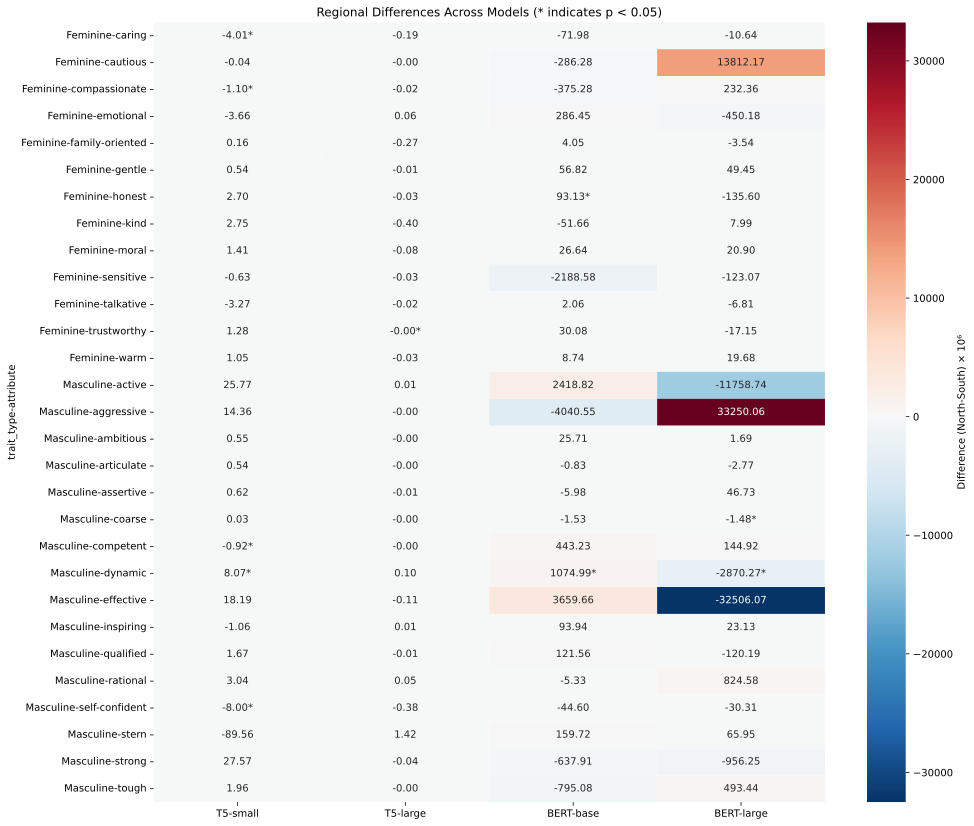

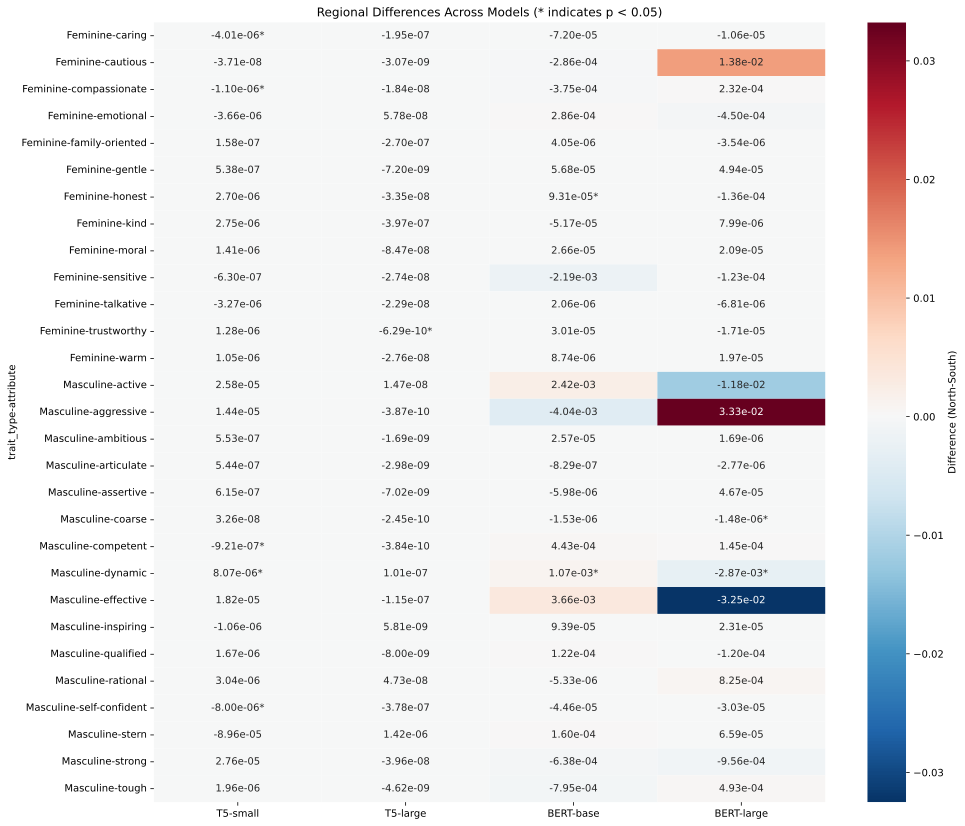

In [ ]:
# Create a combined visualization showing effect size with significance indicators
# Define the desired column and model order
desired_models = ["t5_small", "t5_large", "bert_base", "bert_large"]
desired_display_names = ["T5-small", "T5-large", "BERT-base", "BERT-large"]

# Create a matrix of difference values with the original order
effect_matrix = merged_df.pivot_table(
    index=['trait_type', 'attribute'],
    values=[f'Diff (N-S)_{model}' for model in desired_models],
    aggfunc='first'
)

# Create a corresponding p-value matrix
p_value_matrix = merged_df.pivot_table(
    index=['trait_type', 'attribute'],
    values=[f'p-value_{model}' for model in desired_models],
    aggfunc='first'
)

# Create a significance matrix (boolean)
sig_matrix = p_value_matrix < 0.05

# Scale the values by multiplying by 10^6 (a million) to avoid scientific notation
scaled_matrix = effect_matrix * 1000000

# Rename columns to display names before reordering
display_names_map = {
    f'Diff (N-S)_{desired_models[i]}': desired_display_names[i] 
    for i in range(len(desired_models))
}
scaled_matrix.columns = [display_names_map.get(col, col) for col in scaled_matrix.columns]

# Here's the key fix: manually reorder the columns to the exact order you want
# This changes both the data AND the labels
new_order = ["T5-small", "T5-large", "BERT-base", "BERT-large"]  # Your desired order
scaled_matrix = scaled_matrix[new_order]  # Reorder the actual data columns

# Update p-value column names to match display names for consistent indexing
p_value_display_map = {
    f'p-value_{desired_models[i]}': f'p-value_{desired_display_names[i]}' 
    for i in range(len(desired_models))
}
p_value_matrix.columns = [p_value_display_map.get(col, col) for col in p_value_matrix.columns]

# Reorder p-value matrix columns to match
p_value_new_order = [f'p-value_{model}' for model in new_order]
p_value_matrix = p_value_matrix[p_value_new_order]

# Reorder significance matrix to match
sig_matrix.columns = p_value_matrix.columns
sig_matrix = sig_matrix[p_value_new_order]

# Format annotation matrix with the new order
formatted_values = pd.DataFrame(index=scaled_matrix.index, columns=scaled_matrix.columns)

# For each cell, format the value and add asterisk if significant
for col_idx, col in enumerate(scaled_matrix.columns):
    sig_col = p_value_new_order[col_idx]  # Get corresponding p-value column
    
    for idx in scaled_matrix.index:
        effect_val = scaled_matrix.loc[idx, col]
        is_sig = sig_matrix.loc[idx, sig_col] if idx in sig_matrix.index and sig_col in sig_matrix.columns else False
        
        if pd.notna(effect_val):
            if is_sig:
                formatted_values.loc[idx, col] = f"{effect_val:.2f}*"
            else:
                formatted_values.loc[idx, col] = f"{effect_val:.2f}"
        else:
            formatted_values.loc[idx, col] = "N/A"

# Create the heatmap with properly reordered data and labels
plt.figure(figsize=(14, max(10, len(scaled_matrix) * 0.4)))
sns.heatmap(scaled_matrix, cmap="RdBu_r", center=0, annot=formatted_values, fmt="",
            cbar_kws={'label': 'Difference (North-South) × 10⁶'})
plt.title('Regional Differences Across Models (* indicates p < 0.05)')
plt.tight_layout()
plt.savefig(f"{output_dir}/scaled_differences_heatmap.png", dpi=300)

# Also create the original visualization with scientific notation
# Start with the original effect matrix
effect_matrix.columns = [display_names_map.get(col, col) for col in effect_matrix.columns]
effect_matrix = effect_matrix[new_order]  # Reorder columns

formatted_values_original = pd.DataFrame(index=effect_matrix.index, columns=effect_matrix.columns)

# Format the original values with scientific notation
for col_idx, col in enumerate(effect_matrix.columns):
    sig_col = p_value_new_order[col_idx]  # Get corresponding p-value column
    
    for idx in effect_matrix.index:
        effect_val = effect_matrix.loc[idx, col]
        is_sig = sig_matrix.loc[idx, sig_col] if idx in sig_matrix.index and sig_col in sig_matrix.columns else False
        
        if pd.notna(effect_val):
            if is_sig:
                formatted_values_original.loc[idx, col] = f"{effect_val:.2e}*"
            else:
                formatted_values_original.loc[idx, col] = f"{effect_val:.2e}"
        else:
            formatted_values_original.loc[idx, col] = "N/A"

plt.figure(figsize=(14, max(10, len(effect_matrix) * 0.4)))
sns.heatmap(effect_matrix, cmap="RdBu_r", center=0, annot=formatted_values_original, fmt="",
            cbar_kws={'label': 'Difference (North-South)'})
plt.title('Regional Differences Across Models (* indicates p < 0.05)')
plt.tight_layout()
plt.savefig(f"{output_dir}/combined_effect_significance_heatmap.png", dpi=300)

# Gender Differences

In [8]:
%config InlineBackend.figure_format = 'svg'

In [9]:
pip install tabulate

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import numpy as np
from tabulate import tabulate
import matplotlib.pyplot as plt
import seaborn as sns

# Define file paths for each model
t5_small_path = "/data/########/facct/analysis_results/gender_personal_ttest_results_t5_small.csv"
t5_large_path = "/data/########/facct/analysis_results_t5large/gender_personal_ttest_results_t5_large.csv"
bert_base_path = "/data/########/facct/analysis_results_bert_base_uncased/gender_personal_ttest_results_bert_base.csv"
bert_large_path = "/data/########/facct/analysis_results_bert_large_uncased/gender_personal_ttest_results_bert_large.csv"

# Ensure consistent model order throughout the code
MODEL_ORDER = ["T5-small", "T5-large", "BERT-base", "BERT-large"]

# Function to read and process each model file
def read_model_data(file_path, model_name):
    """
    Read model data for gender differences in personal traits
    Returns a DataFrame with trait type, attribute, diff (M-F), and p-value
    """
    try:
        df = pd.read_csv(file_path)
        
        # Print column names to debug
        print(f"Columns in {file_path}: {df.columns.tolist()}")
        
        # Keep only the significant results
        if 'significant' in df.columns:
            sig_results = df[df['significant'] == True].copy()
        else:
            # If no significant column, use p_value < 0.05
            sig_results = df[df['p_value'] < 0.05].copy()
        
        # Create a new DataFrame with the columns we need, using the actual column names from the file
        result_df = pd.DataFrame({
            'trait_type': sig_results['trait_type'],
            'attribute': sig_results['attribute'],
            'Diff (M-F)': sig_results['diff'],
            'p-value': sig_results['p_value']
        })
        
        result_df['model'] = model_name
        
        return result_df
        
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return pd.DataFrame(columns=['trait_type', 'attribute', 'Diff (M-F)', 'p-value', 'model'])

# Read data from each model
try:
    # Print a message to show progress
    print("Reading model data files...")
    
    # Create a dictionary to store dataframes
    model_dfs = {}
    model_files = {
        "T5-small": t5_small_path,
        "T5-large": t5_large_path,
        "BERT-base": bert_base_path,
        "BERT-large": bert_large_path
    }
    
    # Read each model file
    for model_name, file_path in model_files.items():
        model_dfs[model_name] = read_model_data(file_path, model_name)
    
    # Create a set of all attributes that are significant in at least one model
    all_attrs = set()
    for model_name in MODEL_ORDER:
        if not model_dfs[model_name].empty:
            all_attrs.update(model_dfs[model_name]['attribute'].unique())
    
    print(f"Found {len(all_attrs)} attributes with significant gender differences across models")
    
    # Create a merged DataFrame with all significant attributes
    result_data = []
    for trait_type in ['Masculine', 'Feminine']:
        trait_attrs = sorted([attr for attr in all_attrs 
                             if any(((not model_dfs[model_name].empty) and 
                                     ((model_dfs[model_name]['trait_type'] == trait_type) & 
                                      (model_dfs[model_name]['attribute'] == attr)).any()) 
                                   for model_name in MODEL_ORDER)])
        
        for attr in trait_attrs:
            row = [trait_type, attr]
            
            # Add data for each model (diff and p-value) in the specified order
            for model_name in MODEL_ORDER:
                df = model_dfs[model_name]
                model_data = df[(df['trait_type'] == trait_type) & (df['attribute'] == attr)]
                if not model_data.empty:
                    diff_val = model_data['Diff (M-F)'].values[0]
                    p_val = model_data['p-value'].values[0]
                    row.extend([f"{diff_val:.4f}", f"{p_val:.4f}"])
                else:
                    row.extend(["--", "--"])  # No significant finding
            
            result_data.append(row)
    
    # Create the final table
    columns = ["Trait Type", "Attribute"]
    for model_name in MODEL_ORDER:
        columns.extend(["Diff (M-F)", "p-value"])
    
    # Format and print the table for display
    result_df = pd.DataFrame(result_data, columns=columns)
    styled_table = tabulate(result_data, headers=columns, tablefmt="pipe", showindex=False)
    
    # Add model names as a header row
    model_header = "| | |"
    for model_name in MODEL_ORDER:
        model_header += f" {model_name} | |"
    styled_table = model_header + "\n" + styled_table
    
    print("\nTable 4: Significant Gender Differences in Personal Traits\n")
    print(styled_table)
    
    # Export to LaTeX format (for academic papers)
    # Create a MultiIndex DataFrame for better LaTeX output
    multi_columns = pd.MultiIndex.from_product([MODEL_ORDER, ["Diff (M-F)", "p-value"]])
    
    # Extract just the data values (without trait type and attribute)
    data_values = [row[2:] for row in result_data]
    
    # Convert string values to float where possible
    for i in range(len(data_values)):
        for j in range(len(data_values[i])):
            try:
                if data_values[i][j] != "--":
                    data_values[i][j] = float(data_values[i][j])
            except:
                pass
    
    # Create MultiIndex DataFrame
    multi_df = pd.DataFrame(
        data_values,
        index=pd.MultiIndex.from_tuples([(t, a) for t, a in zip([row[0] for row in result_data], 
                                                              [row[1] for row in result_data])]),
        columns=multi_columns
    )
    multi_df.index.names = ['Trait Type', 'Attribute']
    
    # Convert -- to NaN for LaTeX export
    multi_df = multi_df.replace('--', np.nan)
    
    # Export to LaTeX
    latex_table = multi_df.to_latex(bold_rows=True, multicolumn_format='c', 
                                    longtable=True, caption="Significant Gender Differences in Personal Traits")
    with open("table4_gender_differences.tex", "w") as f:
        f.write(latex_table)
    
    # Export to CSV
    result_df.to_csv("table4_gender_differences.csv", index=False)
    
    # Create a visualization of significant attributes
    # Reshape data for visualization
    viz_data = []
    for model_name in MODEL_ORDER:
        df = model_dfs[model_name]
        for _, row in df.iterrows():
            viz_data.append({
                'Model': model_name,
                'Trait Type': row['trait_type'],
                'Attribute': row['attribute'],
                'Diff (M-F)': row['Diff (M-F)'],
                'p-value': row['p-value']
            })
    
    viz_df = pd.DataFrame(viz_data)
    
    if not viz_df.empty:
        # Create separate visualizations for Masculine and Feminine traits
        for trait_type in ['Masculine', 'Feminine']:
            trait_df = viz_df[viz_df['Trait Type'] == trait_type]
            
            if not trait_df.empty:
                # Create a pivot table for the heatmap
                pivot_df = trait_df.pivot_table(
                    index='Attribute', 
                    columns='Model', 
                    values='Diff (M-F)',
                    aggfunc='first'
                ).fillna(0)
                
                # Ensure the columns are in the right order
                available_models = [model for model in MODEL_ORDER if model in pivot_df.columns]
                pivot_df = pivot_df[available_models]
                
                # Sort by average difference magnitude
                pivot_df['avg_abs'] = pivot_df.abs().mean(axis=1)
                pivot_df = pivot_df.sort_values('avg_abs', ascending=False).drop('avg_abs', axis=1)
                
                # Adjust color scale based on data range
                vmax = max(abs(pivot_df.min().min()), abs(pivot_df.max().max()))
                vmin = -vmax
                
                # Plot heatmap
                plt.figure(figsize=(10, max(6, len(pivot_df) * 0.5)))
                sns.heatmap(pivot_df, cmap="RdBu_r", center=0, vmin=vmin, vmax=vmax,
                            annot=True, fmt=".4f", linewidths=.5)
                plt.title(f"Figure 4{trait_type[0]}: Gender Differences in {trait_type} Traits Across Models")
                plt.ylabel("Attribute")
                plt.xlabel("Model")
                plt.tight_layout()
                plt.savefig(f"figure4_{trait_type.lower()}_traits.png", dpi=300, bbox_inches='tight')
                plt.close()
        
        # Create a combined visualization
        # Group by attribute and calculate mean difference for sorting
        attr_means = viz_df.groupby(['Trait Type', 'Attribute'])['Diff (M-F)'].mean().abs()
        top_attrs = attr_means.sort_values(ascending=False).index[:15]  # Top 15 attributes
        
        # Filter for top attributes
        top_viz_df = viz_df[viz_df.set_index(['Trait Type', 'Attribute']).index.isin(top_attrs)]
        
        # Create a pivot table for combined heatmap
        combined_pivot = top_viz_df.pivot_table(
            index=['Trait Type', 'Attribute'], 
            columns='Model', 
            values='Diff (M-F)',
            aggfunc='first'
        ).fillna(0)
        
        # Ensure the columns are in the right order
        available_models = [model for model in MODEL_ORDER if model in combined_pivot.columns]
        combined_pivot = combined_pivot[available_models]
        
        # Plot combined heatmap
        plt.figure(figsize=(10, 12))
        vmax = max(abs(combined_pivot.min().min()), abs(combined_pivot.max().max()))
        sns.heatmap(combined_pivot, cmap="RdBu_r", center=0, vmin=-vmax, vmax=vmax,
                    annot=True, fmt=".4f", linewidths=.5)
        plt.title("Gender Differences in Personal Traits Across Models")
        plt.tight_layout()
        plt.savefig("figure4_combined_traits.png", dpi=300, bbox_inches='tight')
        plt.close()
    
    print("\nTable and visualizations created successfully!")

except FileNotFoundError as e:
    print(f"Error: {e}")
    print("Please ensure all four model data files exist in the correct location.")
except Exception as e:
    print(f"An error occurred: {e}")
    import traceback
    traceback.print_exc()

Reading model data files...
Columns in /data/kell7799/facct/analysis_results/gender_personal_ttest_results_t5_small.csv: ['attribute', 'trait_type', 'male_mean', 'female_mean', 'diff', 't_statistic', 'p_value', 'significant', 'effect_size', 'abs_diff']
Columns in /data/kell7799/facct/analysis_results_t5large/gender_personal_ttest_results_t5_large.csv: ['attribute', 'trait_type', 'male_mean', 'female_mean', 'diff', 't_statistic', 'p_value', 'significant', 'effect_size', 'abs_diff']
Columns in /data/kell7799/facct/analysis_results_bert_base_uncased/gender_personal_ttest_results_bert_base.csv: ['attribute', 'trait_type', 'male_mean', 'female_mean', 'diff', 't_statistic', 'p_value', 'significant', 'effect_size', 'abs_diff']
Columns in /data/kell7799/facct/analysis_results_bert_large_uncased/gender_personal_ttest_results_bert_large.csv: ['attribute', 'trait_type', 'male_mean', 'female_mean', 'diff', 't_statistic', 'p_value', 'significant', 'effect_size', 'abs_diff']
Found 22 attributes with

/tmp/ipykernel_2250055/393717765.py:146: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  multi_df = multi_df.replace('--', np.nan)



Table and visualizations created successfully!



Combined Traits Visualization:


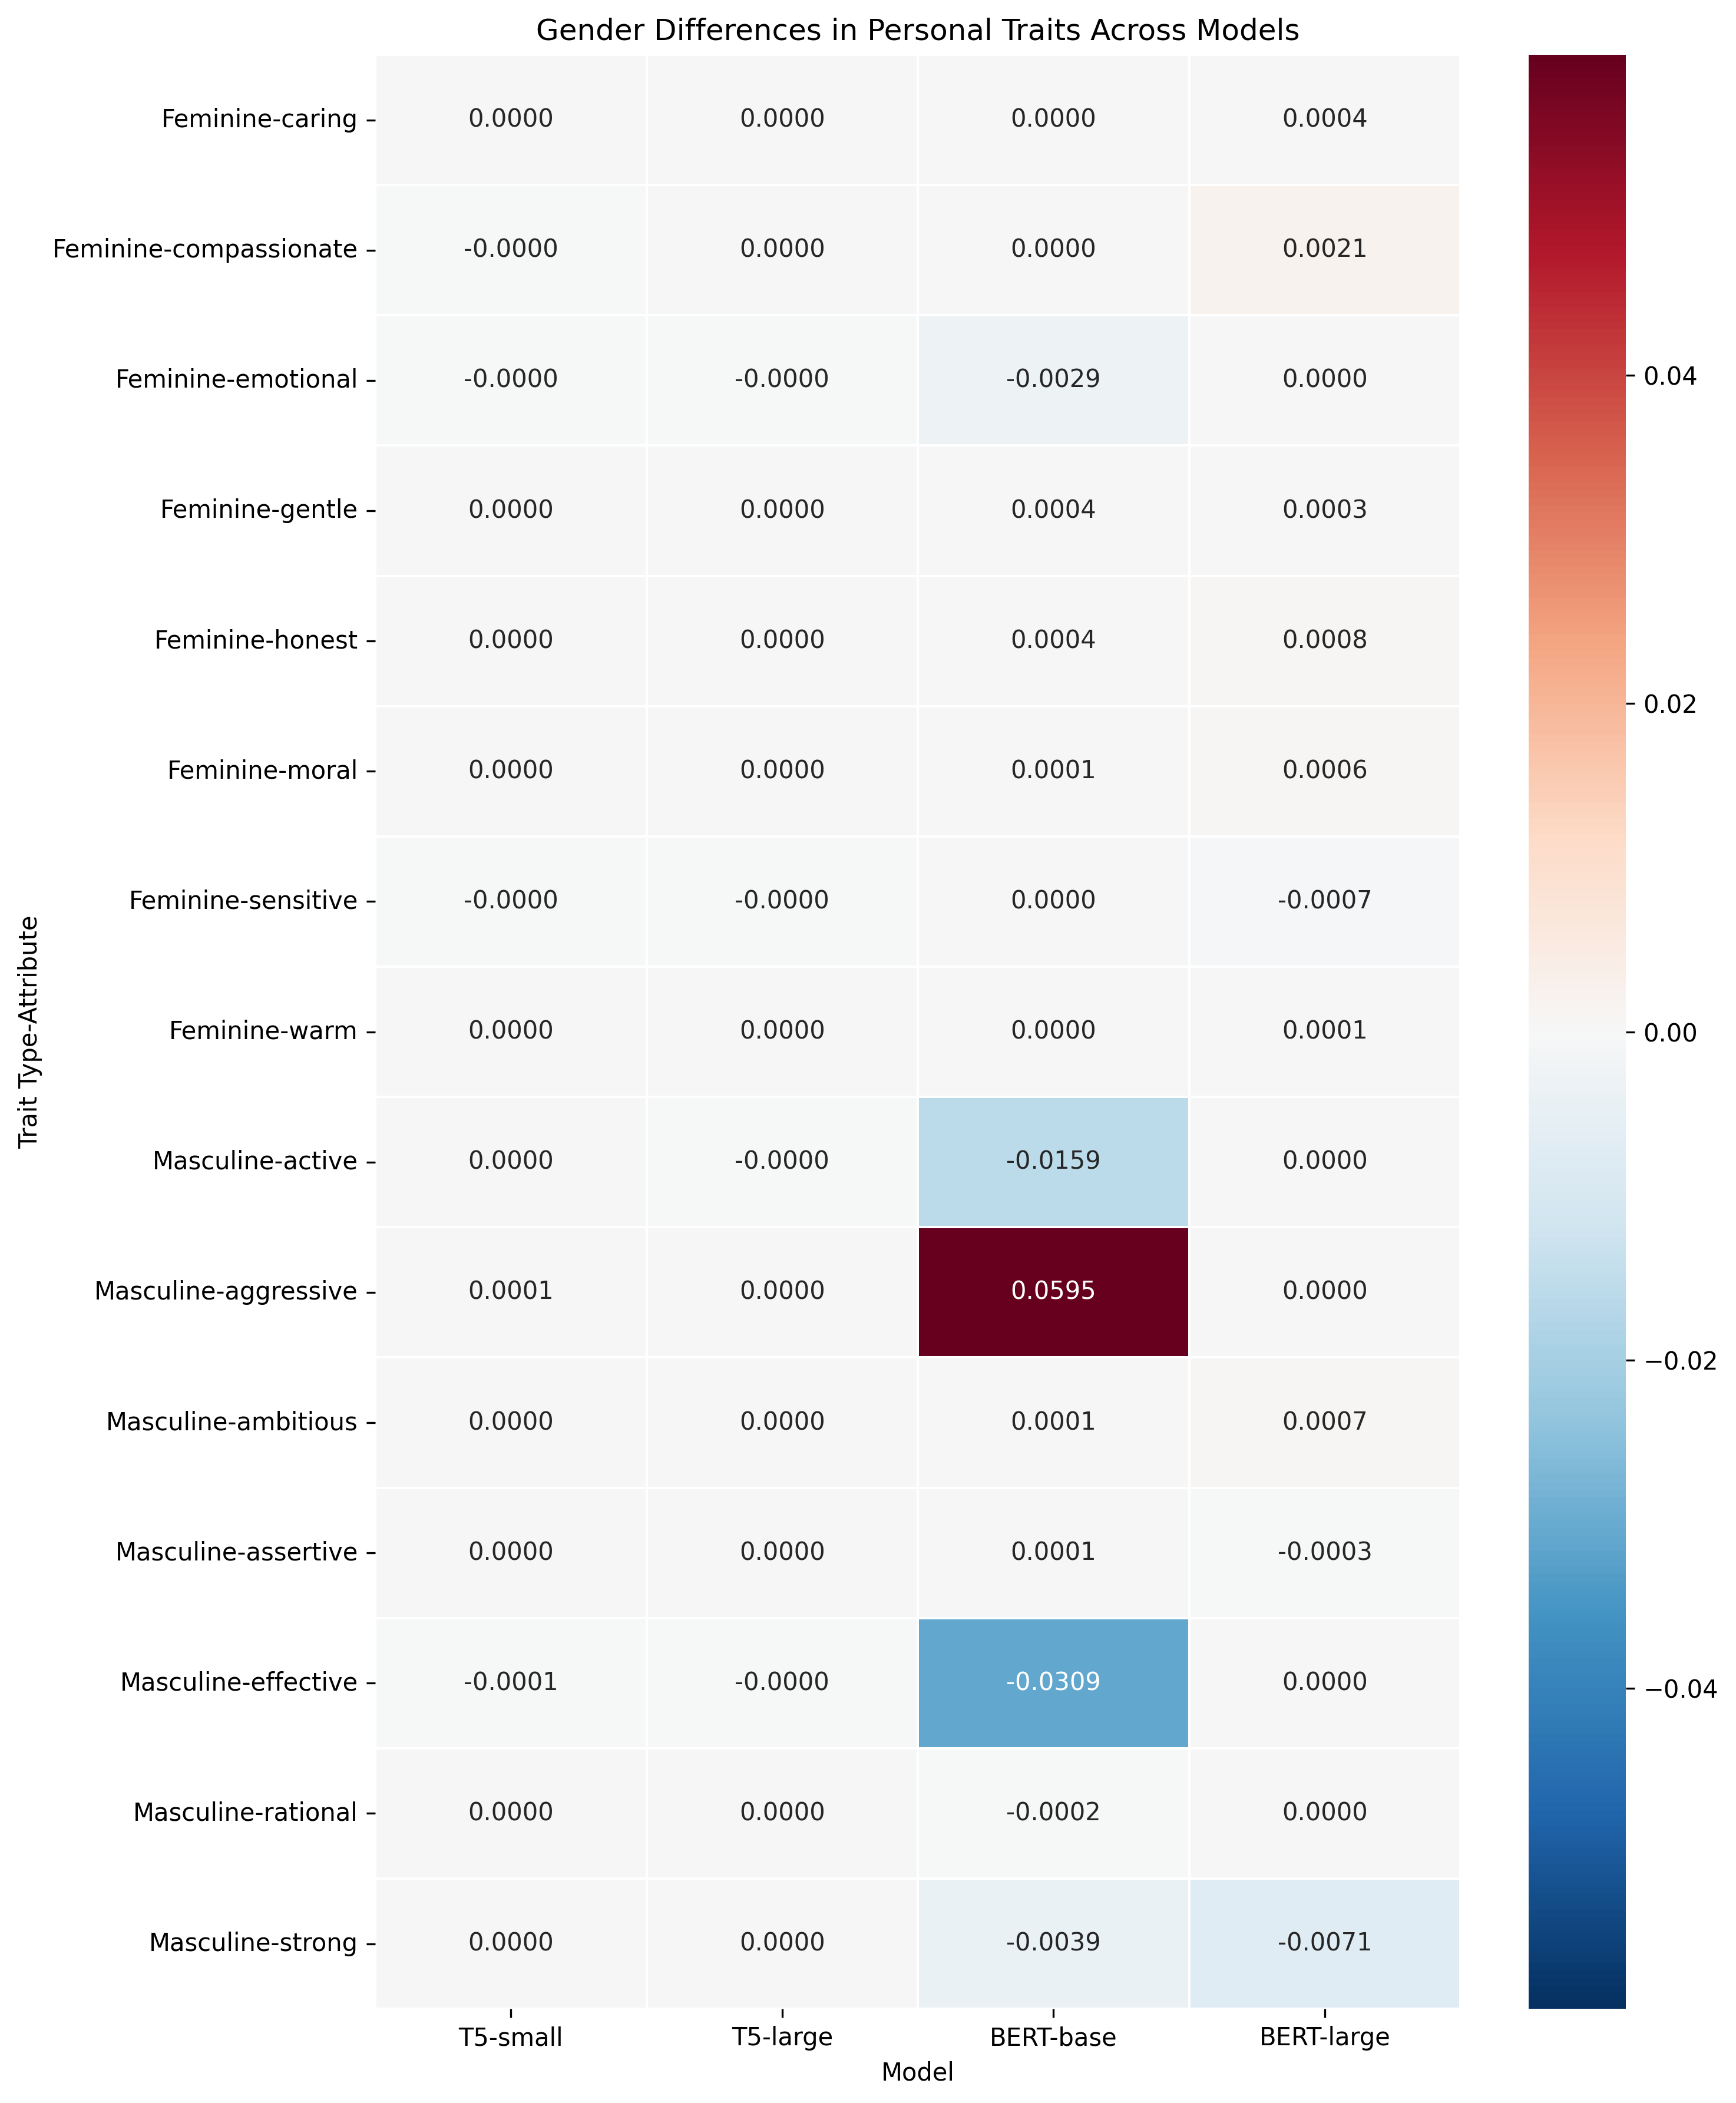

In [28]:
# # Display the masculine traits visualization
# print("Masculine Traits Visualization:")
# display(SVG("figure4_masculine_traits.svg"))

# # Display the feminine traits visualization
# print("\nFeminine Traits Visualization:")
# display(SVG("figure4_feminine_traits.svg"))

# Display the combined visualization
from IPython.display import Image, display
print("\nCombined Traits Visualization:")
display(Image("figure4_combined_traits.png"))

# # Display the publication-ready visualization
# print("\nPublication-Ready Visualization:")
# display(SVG("figure4_traits_publication.svg"))